In [1]:
import pandas as pd

# Load the clip labels created from Process_boxes_to_classifier_labels.ipynb
train_set = pd.read_csv('train_set_onehot.csv')
val_set = pd.read_csv('val_set_onehot.csv')
test_set = pd.read_csv('test_set_onehot.csv')

# concat all subsets in dataset df
dataset_df = pd.concat([train_set, val_set, test_set], ignore_index=True)

dataset_df

,file,start_time,end_time,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_G,calltype_J,calltype_K
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5728,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,False,False,False,True,False
5729,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
5730,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
5731,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False


In [2]:
classes = dataset_df.columns[3:].tolist()
classes

['calltype_A',
 'calltype_B',
 'calltype_C',
 'calltype_Check',
 'calltype_Cheer',
 'calltype_Chits',
 'calltype_D',
 'calltype_E',
 'calltype_G',
 'calltype_J',
 'calltype_K']

In [3]:
# make index file and start time and end time
train_set = train_set.reset_index(drop=True)
val_set = val_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

# train_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
# val_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
# test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)

optional: upsampling or downsampling

In [4]:
train_set.head()

,file,start_time,end_time,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_G,calltype_J,calltype_K
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False


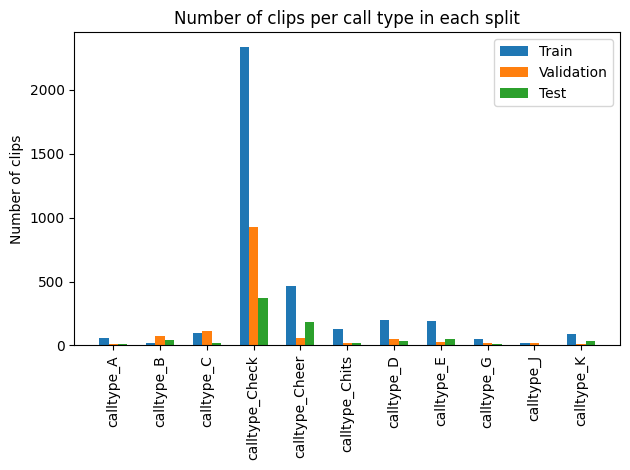

In [5]:
# bar plot number of calltype files in each split
import matplotlib.pyplot as plt
calltype_columns = [col for col in classes if col.startswith('calltype_')]
train_counts = train_set[calltype_columns].sum()
val_counts = val_set[calltype_columns].sum()
test_counts = test_set[calltype_columns].sum()
x = range(len(calltype_columns))
plt.bar(x, train_counts, width=0.2, label='Train')
plt.bar([i + 0.2 for i in x], val_counts, width=0.2, label='Validation')
plt.bar([i + 0.4 for i in x], test_counts, width=0.2, label='Test')
plt.xticks([i + 0.2 for i in x], calltype_columns, rotation=90)
plt.ylabel('Number of clips')
plt.title('Number of clips per call type in each split')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# print table of number of calltype files in each split
split_summary = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
})
split_summary

,Train,Validation,Test
calltype_A,55,9,12
calltype_B,17,74,45
calltype_C,97,112,19
calltype_Check,2333,930,367
calltype_Cheer,464,59,184
calltype_Chits,125,18,19
calltype_D,195,47,34
calltype_E,192,29,51
calltype_G,47,18,12
calltype_J,19,16,4


### resample

In [ ]:
# resample train set by upsampling minority classes
seed = 42

def resample_set(df, n_samples_per_class, seed=42, downsample=True, upsample=True):
    """
    Resample a multi-label dataset to have n_samples_per_class for each class.
    For upsampling: duplicates rows as needed (keeps duplicates)
    For downsampling: randomly selects subset of samples
    """
    resampled_dfs = []
    
    # Get label columns (exclude metadata columns)
    label_cols = [col for col in df.columns if col not in ['file', 'start_time', 'end_time']]
    
    for class_label in label_cols:
        # Get rows that have this class
        class_df = df[df[class_label] == 1].copy()
        
        if len(class_df) == 0:
            print(f"Warning: No samples found for {class_label}")
            continue
        
        # Sample with or without replacement depending on class size
        if len(class_df) < n_samples_per_class and upsample:
            # Upsample with replacement - this creates duplicates
            sampled_df = class_df.sample(
                n=n_samples_per_class, replace=True, random_state=seed
            )
            new_number = len(sampled_df)
            print(f"Upsampled {class_label} from {len(class_df)} to {new_number} clips.")
        elif len(class_df) > n_samples_per_class and downsample:
            # Downsample
            sampled_df = class_df.sample(
                n=n_samples_per_class, replace=False, random_state=seed
            )

            new_number = len(sampled_df)
            print(f"Downsampled {class_label} from {len(class_df)} to {new_number} clips.")
        else:
            sampled_df = class_df
        resampled_dfs.append(sampled_df)
    
    # Concatenate all resampled dataframes and remove duplicates
    # (a clip can appear multiple times if it belongs to multiple classes that were all upsampled)
    resampled_set = pd.concat(resampled_dfs, axis=0)
    resampled_set = resampled_set.reset_index(drop=True)
    
    print(f"\nTotal unique clips after resampling: {len(resampled_set)}")
    
    # Show per-class counts after resampling
    print("\nPer-class counts after resampling:")
    for col in label_cols:
        count = resampled_set[col].sum()
        print(f"  {col}: {count}")
    
    return resampled_set

In [ ]:
RESAMPLE = True
RESAMPLE_VAL = True
DOWNSAMPLE = True
UPSAMPLE = True

if RESAMPLE:
    resampled_train_set = resample_set(train_set, 100, seed, downsample=DOWNSAMPLE, upsample=UPSAMPLE)
    resampled_train_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
    print("\nResampled training set created.")
    if RESAMPLE_VAL:
        resampled_val_set = resample_set(val_set, 100, seed, downsample=DOWNSAMPLE, upsample=False)
        print("\nResampled validation set created.")
    else:
        resampled_val_set = val_set.copy()
    resampled_val_set.set_index(['file', 'start_time', 'end_time'], inplace=True)  
    test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
else:
    resampled_train_set = train_set.set_index(['file', 'start_time', 'end_time'])
    resampled_val_set = val_set.set_index(['file', 'start_time', 'end_time'])
    test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)

In [9]:
resampled_train_set

,,,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_G,calltype_J,calltype_K
file,start_time,end_time,,,,,,,,,,,
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL07_Trial_1_trim_37.44715902_37.57169857_D.WAV,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL10_Trial_1_trim_47.70134954_48.36720022_Cheer.WAV,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/AZ13_Trial_3_trim_21.29153733_21.35859514_Check.WAV,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL51_Trial_1_trim_57.29257191_58.21124032_Cheer.WAV,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/AZ15_Trial_1_trim_17.73289918_17.82390596_Check.WAV,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/EF04_Trial_3_trim_18.05885722_18.41862923_G.WAV,0.0,3.0,False,False,False,False,False,False,False,False,True,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/AZ13_Trial_1_trim_41.66087247_41.73991969_Check.WAV,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL07_Trial_1_trim_1.432204814_1.504054554_Check.WAV,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False


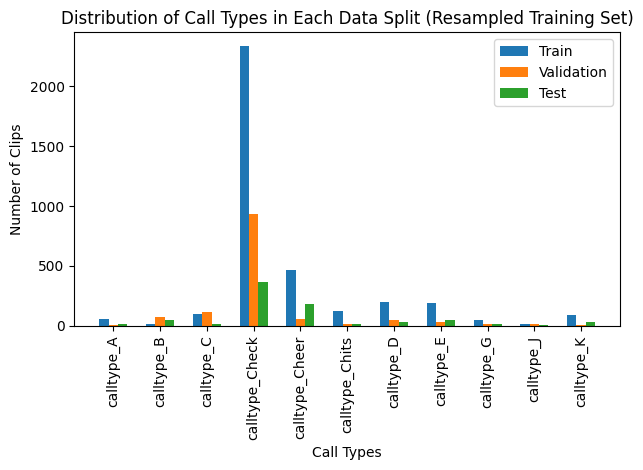

In [10]:
# bar plot number of calltype files in each split resampled
import matplotlib.pyplot as plt
calltype_columns = [col for col in dataset_df.columns if col.startswith('calltype_')]
train_counts = resampled_train_set[calltype_columns].sum()
val_counts = resampled_val_set[calltype_columns].sum()
test_counts = test_set[calltype_columns].sum()
x = range(len(calltype_columns))
plt.bar(x, train_counts, width=0.2, label='Train')
plt.bar([i + 0.2 for i in x], val_counts, width=0.2, label='Validation')
plt.bar([i + 0.4 for i in x], test_counts, width=0.2, label='Test')
plt.xticks([i + 0.2 for i in x], calltype_columns, rotation=90)
plt.xlabel('Call Types')
plt.ylabel('Number of Clips')
plt.title('Distribution of Call Types in Each Data Split (Resampled Training Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# read in the training, validation and test set
import pandas as pd
import bioacoustics_model_zoo as bmz
import torch
import numpy as np

# Allow numpy types to be loaded
torch.serialization.add_safe_globals([np.float32, np.float64, np.int32, np.int64])

birdnet = bmz.BirdNET()
#train_set = pd.read_csv('resampled_train_set.csv', index_col=[0,1,2])
#val_set = pd.read_csv('validation_set.csv', index_col=[0,1,2])

2026-01-29 19:31:41.715569: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


downloading model from URL...


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/home/She

In [12]:

# emb_test = birdnet.embed(test_set, return_dfs=False, batch_size=128, num_workers=num_workers)

In [14]:
num_workers = 4

# emb_train = birdnet.embed(resampled_train_set, return_dfs=False, batch_size=128, num_workers=num_workers)
# emb_val = birdnet.embed(resampled_val_set, return_dfs=False, batch_size=128, num_workers=num_workers)
emb_test = birdnet.embed(test_set, return_dfs=False, batch_size=128, num_workers=num_workers)

  0%|          | 0/7 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=572838) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


In [15]:
# We want to train the classifier on the 'A' class here, corresponding to the primary R. sierrae call type.
# Let's replace fc output layer with 1-output layer for class 'A'
classes = list(resampled_train_set.columns)
birdnet.change_classes(classes)

# Convert all label columns to float to avoid object type errors
resampled_train_set = resampled_train_set.astype(float)
resampled_val_set = resampled_val_set.astype(float)
test_set = test_set.astype(float)
# Convert labels to float (in case they're boolean or object type)
train_labels = resampled_train_set.astype(float).values
val_labels = resampled_val_set.astype(float).values
test_labels = test_set.astype(float).values

# fit the classification head with embeddings and labels
# birdnet.network.fit(emb_train, train_labels, emb_val, val_labels)

In [16]:
import pickle
import os
import sys
from io import StringIO

# Create training directory if it doesn't exist
os.makedirs('training', exist_ok=True)

# Capture stdout to parse training metrics
captured_output = StringIO()
old_stdout = sys.stdout
sys.stdout = captured_output

try:
    # Train the model
    history = birdnet.train(
        train_df=resampled_train_set,
        validation_df=resampled_val_set,
        embedding_batch_size=128,
        embedding_num_workers=num_workers,
        # n_augmentation_variants=2,
        steps=100,
        device=0
    )
finally:
    # Restore stdout
    sys.stdout = old_stdout

# Print captured output
output = captured_output.getvalue()
print(output)

# Parse the captured output to extract metrics
import re
train_losses = []
val_losses = []
val_aurocs = []
val_maps = []
epochs = []

for line in output.split('\n'):
    # Match lines like: "Epoch 100/500, Loss: 0.03169373422861099, Val Loss: 0.11118992418050766"
    epoch_match = re.search(r'Epoch (\d+)/\d+, Loss: ([\d.]+), Val Loss: ([\d.]+)', line)
    if epoch_match:
        epochs.append(int(epoch_match.group(1)))
        train_losses.append(float(epoch_match.group(2)))
        val_losses.append(float(epoch_match.group(3)))
    
    # Match lines like: "val AU ROC: 0.923"
    auroc_match = re.search(r'val AU ROC: ([\d.]+)', line)
    if auroc_match:
        val_aurocs.append(float(auroc_match.group(1)))
    
    # Match lines like: "val MAP: 0.657"
    map_match = re.search(r'val MAP: ([\d.]+)', line)
    if map_match:
        val_maps.append(float(map_match.group(1)))

# Create history dictionary
history = {
    'epochs': epochs,
    'train_loss': train_losses,
    'val_loss': val_losses,
    'val_auroc': val_aurocs,
    'val_map': val_maps
}

print(f"\nParsed {len(epochs)} training checkpoints")

# Save training history
with open('training/training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("Training complete. History saved to 'training/training_history.pkl'")

  0%|          | 0/29 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=572838) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/11 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=572838) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_features = torch.tensor(train_features, dtype=torch.float32, device=device)
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels = torch.tensor(train_labels, dtyp

Embedding the training samples without augmentation
Embedding the validation samples
Fitting the classifier
Epoch 1/100, Loss: 0.6832698583602905, Val Loss: 0.5639067888259888
val AU ROC: 0.558
val MAP: 0.144
Epoch 2/100, Loss: 0.569573700428009, Val Loss: 0.46902966499328613
val AU ROC: 0.539
val MAP: 0.149
Epoch 3/100, Loss: 0.47616657614707947, Val Loss: 0.3929480314254761
val AU ROC: 0.515
val MAP: 0.153
Epoch 4/100, Loss: 0.4014797806739807, Val Loss: 0.3334193527698517
val AU ROC: 0.489
val MAP: 0.155
Epoch 5/100, Loss: 0.3431283235549927, Val Loss: 0.2877861559391022
val AU ROC: 0.469
val MAP: 0.154
Epoch 6/100, Loss: 0.29836028814315796, Val Loss: 0.25336432456970215
val AU ROC: 0.460
val MAP: 0.151
Epoch 7/100, Loss: 0.264445960521698, Val Loss: 0.2277100682258606
val AU ROC: 0.459
val MAP: 0.146
Epoch 8/100, Loss: 0.23893648386001587, Val Loss: 0.2087547779083252
val AU ROC: 0.464
val MAP: 0.143
Epoch 9/100, Loss: 0.21978698670864105, Val Loss: 0.19483569264411926
val AU ROC:

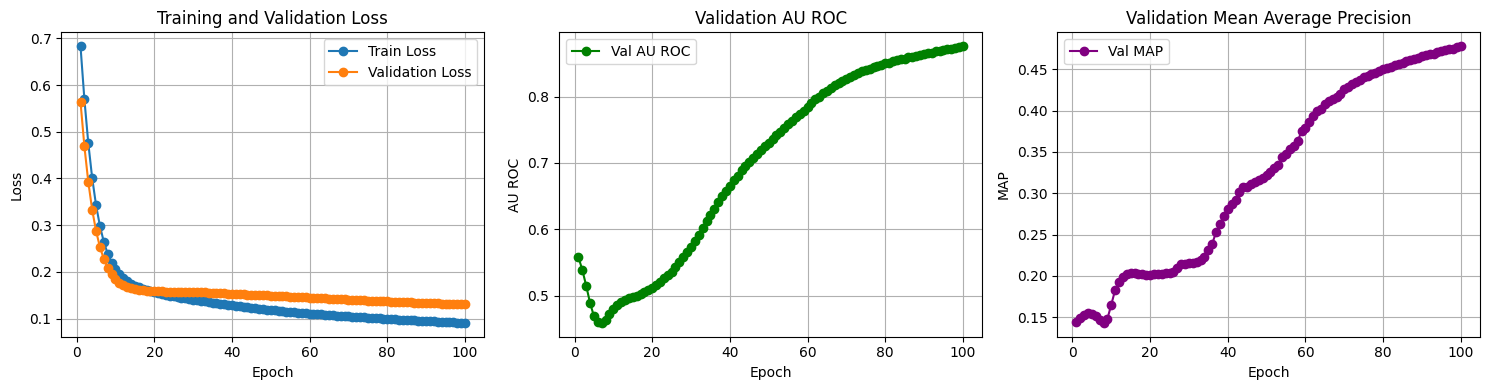


Final Metrics (Epoch 100):
  Train Loss: 0.0908
  Val Loss: 0.1308
  Val AU ROC: 0.8760
  Val MAP: 0.4780


In [17]:
# Plot training curves
import pickle
import matplotlib.pyplot as plt

# Load training history
with open('training/training_history.pkl', 'rb') as f:
    history = pickle.load(f)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot training and validation loss
axes[0].plot(history['epochs'], history['train_loss'], 'o-', label='Train Loss')
axes[0].plot(history['epochs'], history['val_loss'], 'o-', label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot validation AU ROC
axes[1].plot(history['epochs'], history['val_auroc'], 'o-', color='green', label='Val AU ROC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AU ROC')
axes[1].set_title('Validation AU ROC')
axes[1].legend()
axes[1].grid(True)

# Plot validation MAP
axes[2].plot(history['epochs'], history['val_map'], 'o-', color='purple', label='Val MAP')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MAP')
axes[2].set_title('Validation Mean Average Precision')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Metrics (Epoch {history['epochs'][-1]}):")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Val AU ROC: {history['val_auroc'][-1]:.4f}")
print(f"  Val MAP: {history['val_map'][-1]:.4f}")

In [ ]:
# transform preds with softmax to get probabilities
#import torch.nn.functional as F
#preds = birdnet.network(torch.tensor(emb_val)).detach()
#preds = F.softmax(preds, dim=1)
#print(preds.shape)
#preds

torch.Size([1323, 11])


tensor([[5.4609e-06, 3.1078e-06, 1.4245e-05,  ..., 4.4000e-06, 1.0612e-05,
         6.0918e-06],
        [9.7907e-04, 1.3331e-03, 5.5145e-02,  ..., 6.9675e-04, 2.9431e-03,
         2.7309e-03],
        [5.8225e-04, 8.0389e-04, 2.7389e-02,  ..., 4.2899e-04, 1.5016e-03,
         1.5588e-03],
        ...,
        [4.7637e-06, 3.2695e-06, 1.0248e-05,  ..., 6.3114e-06, 9.1676e-06,
         4.3536e-06],
        [1.5750e-01, 9.6397e-03, 5.8924e-04,  ..., 1.0995e-02, 1.6224e-02,
         6.0133e-01],
        [5.2020e-05, 6.0395e-05, 2.0429e-03,  ..., 4.5547e-05, 1.3389e-04,
         9.4918e-05]])

In [19]:
emb_val = birdnet.embed(resampled_val_set, return_dfs=False, batch_size=128, num_workers=num_workers)

  0%|          | 0/11 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=572838) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/tmp/ipykernel_572838/3428758363.py:13: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  plt.hist(preds[tp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='True Positives')


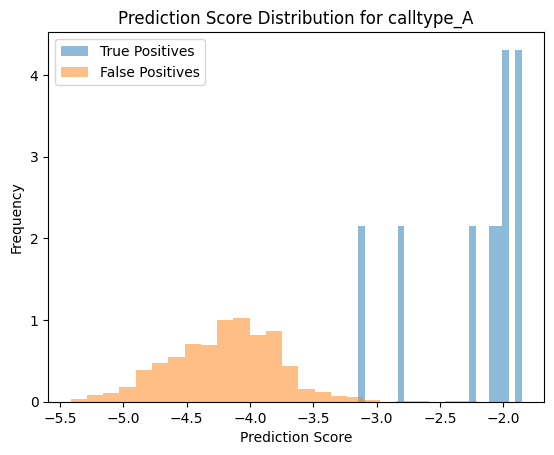

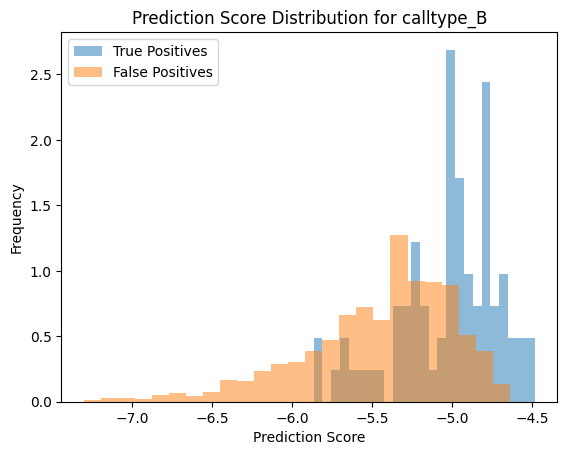

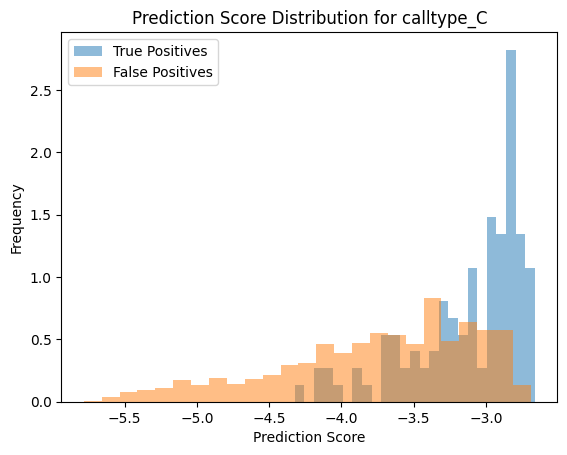

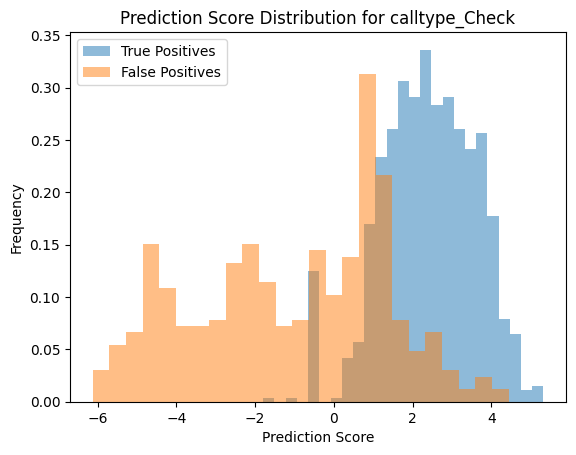

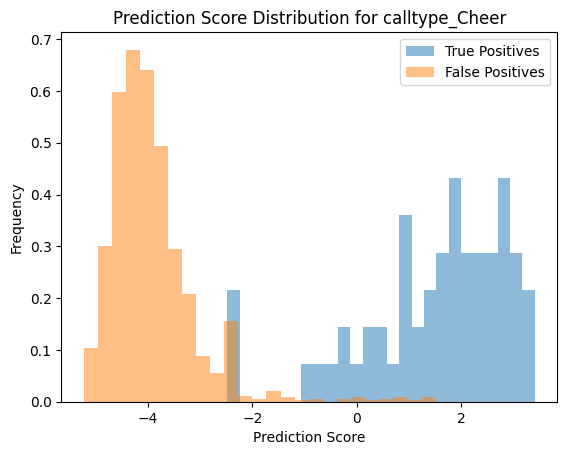

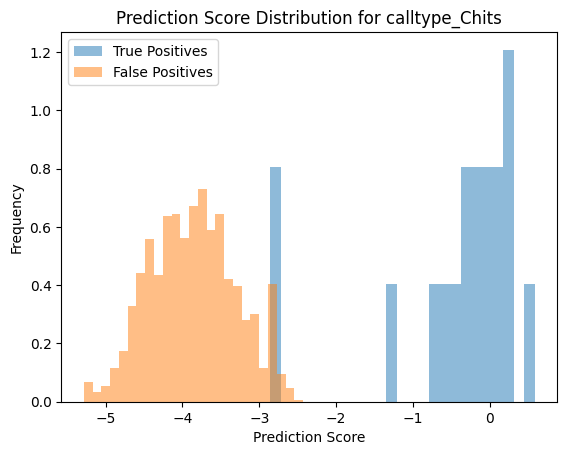

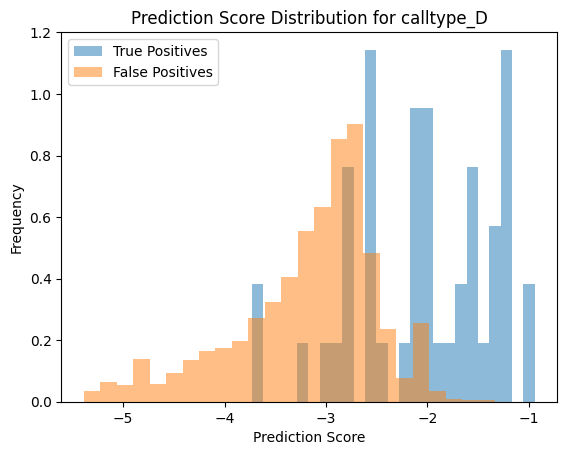

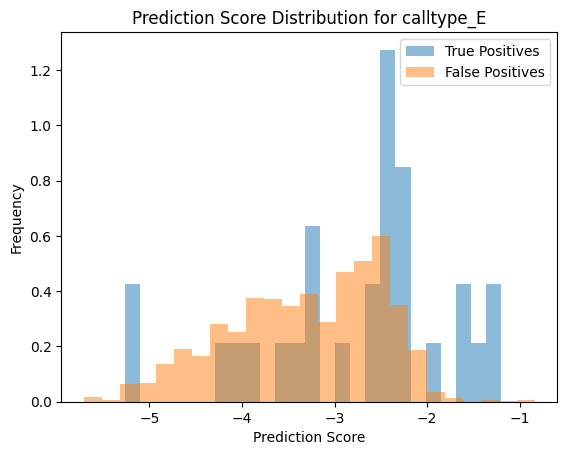

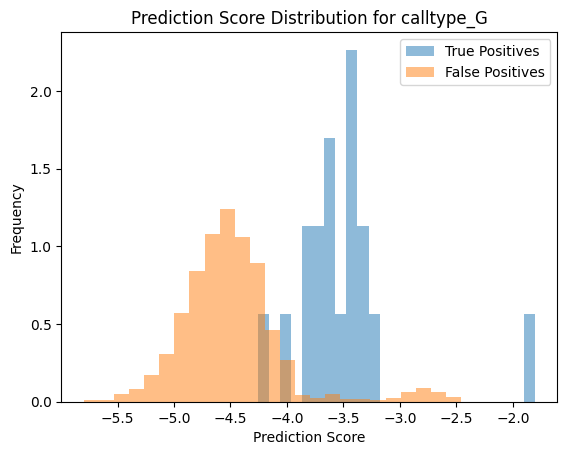

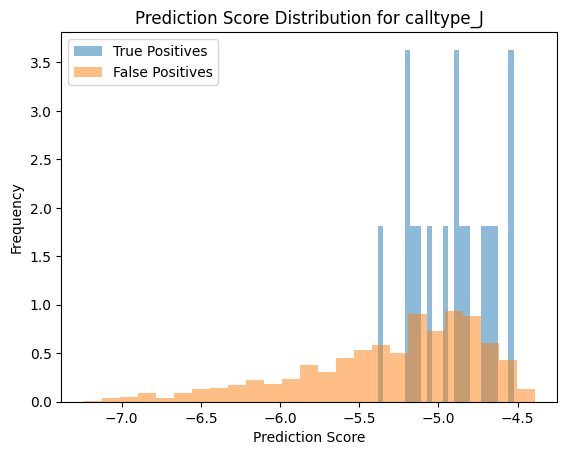

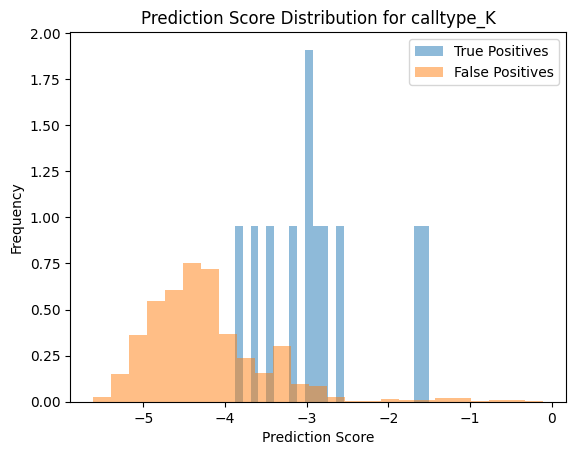

In [21]:
# Plot an histogram per calltype of the prediction scores and FP vs TP
preds = birdnet.network(torch.tensor(emb_val).cuda()).detach().cpu()

import matplotlib.pyplot as plt

for class_name in classes:
    class_idx = list(resampled_val_set.columns).index(class_name) # get index of class
    plt.figure()
    #plt.hist(preds[:, class_idx].numpy(), bins=50, alpha=0.7, label='All Predictions')
    
    # True Positives
    tp_indices = (resampled_val_set[class_name] == 1).values # get indices of true positives
    plt.hist(preds[tp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='True Positives')
    
    # False Positives
    fp_indices = (resampled_val_set[class_name] == 0).values # get indices of false positives
    plt.hist(preds[fp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='False Positives')
    
    plt.title(f'Prediction Score Distribution for {class_name}')
    plt.xlabel('Prediction Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [23]:
#can you write code for a classification report for each class?
from sklearn.metrics import classification_report
# pred class is the class with the highest score
pred_labels = np.argmax(preds.numpy(), axis=1)
resampled_val_set_labels = np.argmax(resampled_val_set.values, axis=1)
report = classification_report(resampled_val_set_labels, pred_labels, target_names=classes, zero_division=0)
print(report)

                precision    recall  f1-score   support

    calltype_A       1.00      0.11      0.20         9
    calltype_B       0.00      0.00      0.00        74
    calltype_C       0.00      0.00      0.00       112
calltype_Check       0.78      1.00      0.88       930
calltype_Cheer       0.72      0.95      0.82        59
calltype_Chits       0.94      0.89      0.91        18
    calltype_D       1.00      0.30      0.46        47
    calltype_E       0.00      0.00      0.00        29
    calltype_G       0.00      0.00      0.00        18
    calltype_J       0.00      0.00      0.00        16
    calltype_K       0.10      0.09      0.10        11

      accuracy                           0.77      1323
     macro avg       0.41      0.30      0.31      1323
  weighted avg       0.64      0.77      0.68      1323



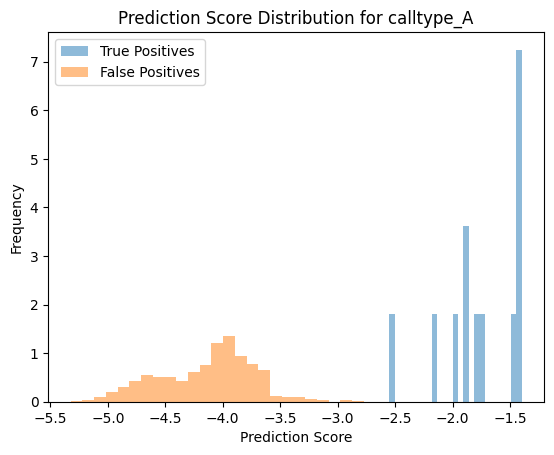

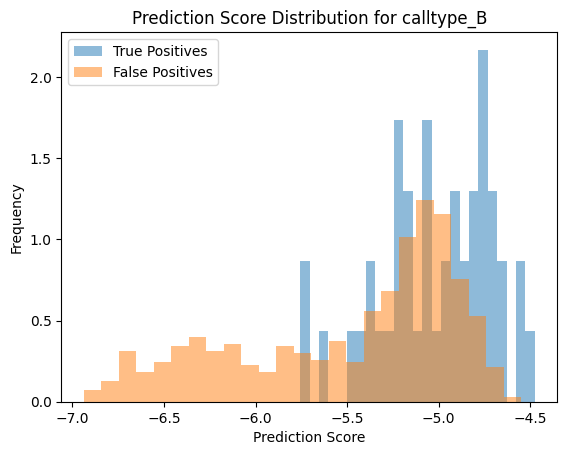

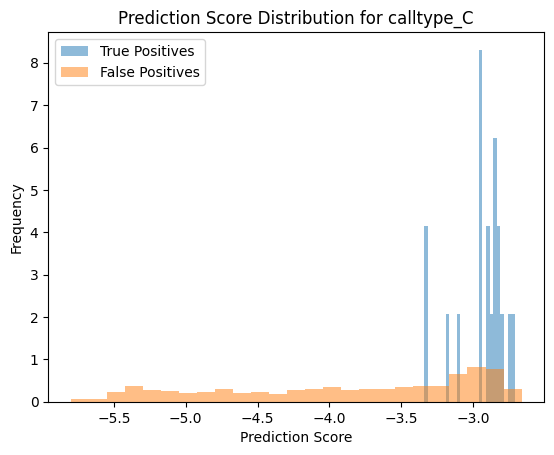

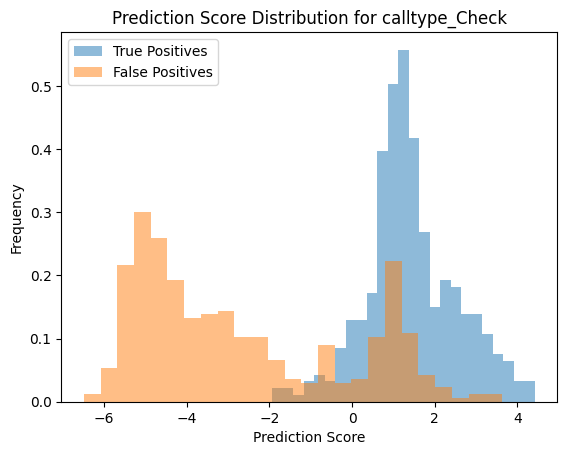

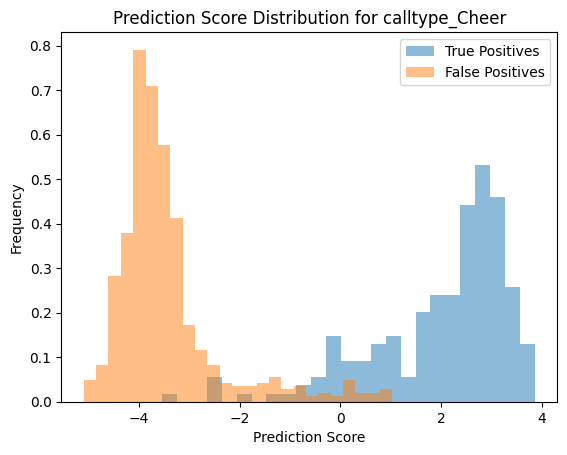

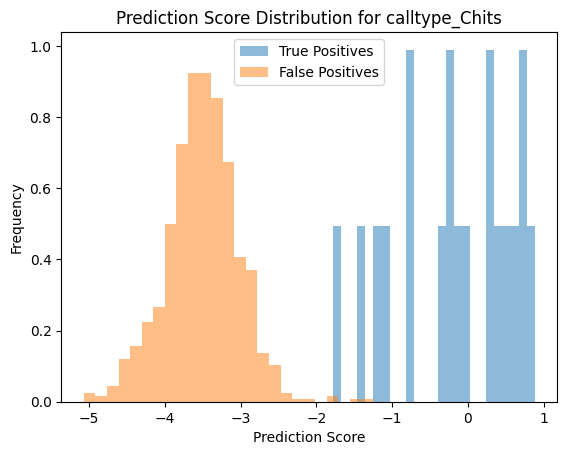

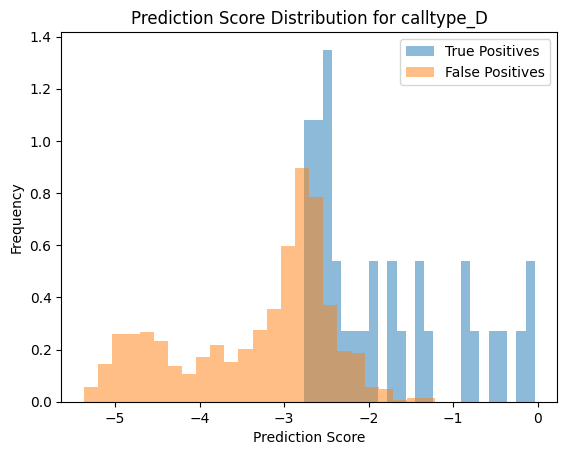

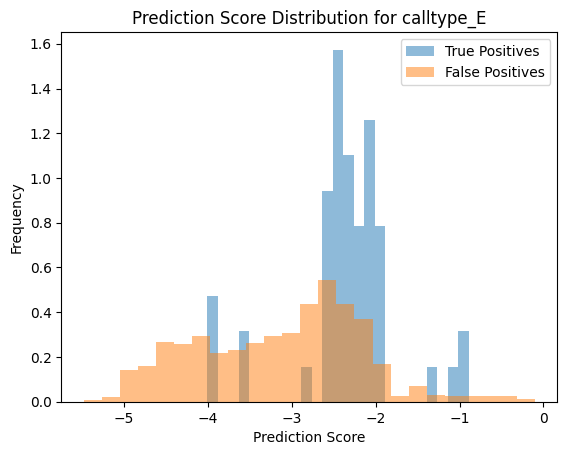

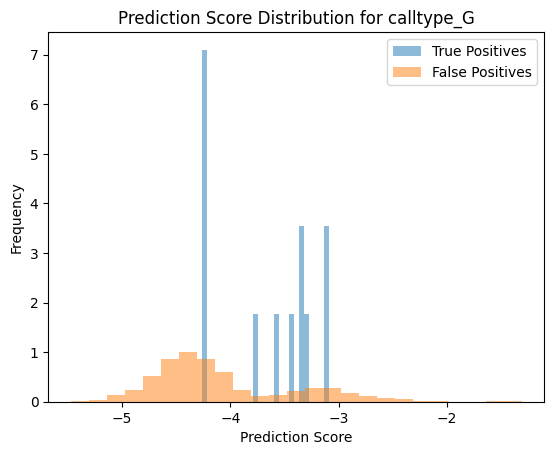

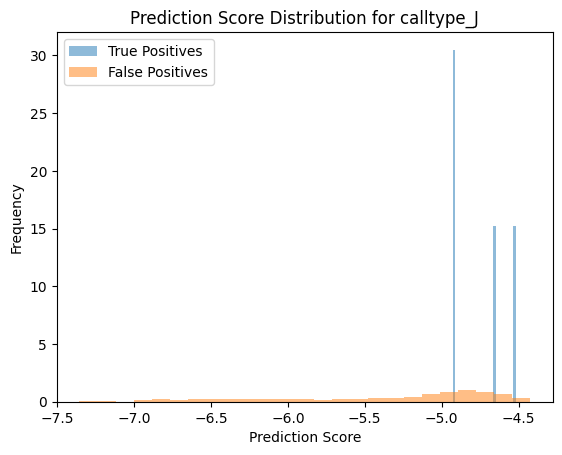

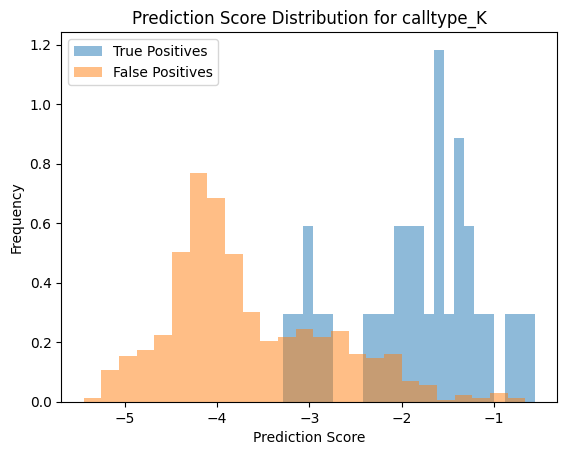

In [25]:
# Plot an histogram per calltype of the prediction scores and FP vs TP
preds = birdnet.network(torch.tensor(emb_test).cuda()).detach().cpu()

import matplotlib.pyplot as plt

for class_name in classes:
    class_idx = list(test_set.columns).index(class_name) # get index of class
    plt.figure()
    #plt.hist(preds[:, class_idx].numpy(), bins=50, alpha=0.7, label='All Predictions')
    
    # True Positives
    tp_indices = (test_set[class_name] == 1).values # get indices of true positives
    plt.hist(preds[tp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='True Positives')
    
    # False Positives
    fp_indices = (test_set[class_name] == 0).values # get indices of false positives
    plt.hist(preds[fp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='False Positives')
    
    plt.title(f'Prediction Score Distribution for {class_name}')
    plt.xlabel('Prediction Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [26]:
from sklearn.metrics import classification_report
# pred class is the class with the highest score
pred_labels = np.argmax(preds.numpy(), axis=1)
test_labels = np.argmax(test_set.values, axis=1)
report = classification_report(test_labels, pred_labels, target_names=classes, zero_division=0)
print(report)

                precision    recall  f1-score   support

    calltype_A       0.00      0.00      0.00        12
    calltype_B       0.00      0.00      0.00        45
    calltype_C       0.00      0.00      0.00        19
calltype_Check       0.75      0.99      0.85       367
calltype_Cheer       0.83      0.98      0.90       184
calltype_Chits       0.94      0.84      0.89        19
    calltype_D       0.83      0.15      0.25        34
    calltype_E       0.11      0.08      0.09        51
    calltype_G       0.00      0.00      0.00        12
    calltype_J       0.00      0.00      0.00         4
    calltype_K       0.14      0.06      0.09        31

      accuracy                           0.73       778
     macro avg       0.33      0.28      0.28       778
  weighted avg       0.62      0.73      0.66       778



In [27]:
# plot a table of number of samples in training set per class and the F1score, precision and recall in test set per class
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
test_set = test_set.astype(float)
# Convert labels to float (in case they're boolean or object type)
train_labels = resampled_train_set.astype(float).values
val_labels = resampled_val_set.astype(float).values
test_labels = test_set.astype(float).values
test_labels = np.argmax(test_set.values, axis=1)
summary_data = []
for i, class_name in enumerate(classes):
    n_samples = resampled_train_set[class_name].sum()
    precision = precision_score(test_labels, pred_labels, average=None, zero_division=0)[i]
    recall = recall_score(test_labels, pred_labels, average=None, zero_division=0)[i]
    f1 = f1_score(test_labels, pred_labels, average=None, zero_division=0)[i]
    summary_data.append({
        'Class': class_name,
        'Num Samples (Train)': n_samples,
        'Precision (Test)': precision,
        'Recall (Test)': recall,
        'F1 Score (Test)': f1
    })
summary_df = pd.DataFrame(summary_data)
summary_df

,Class,Num Samples (Train),Precision (Test),Recall (Test),F1 Score (Test)
0,calltype_A,55.0,0.000000,0.000000,0.000000
1,calltype_B,17.0,0.000000,0.000000,0.000000
2,calltype_C,97.0,0.000000,0.000000,0.000000
3,calltype_Check,2333.0,0.747433,0.991826,0.852459
4,calltype_Cheer,464.0,0.825688,0.978261,0.895522
5,calltype_Chits,125.0,0.941176,0.842105,0.888889
6,calltype_D,195.0,0.833333,0.147059,0.250000
7,calltype_E,192.0,0.111111,0.078431,0.091954
8,calltype_G,47.0,0.000000,0.000000,0.000000
9,calltype_J,19.0,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Confusion Matrix')

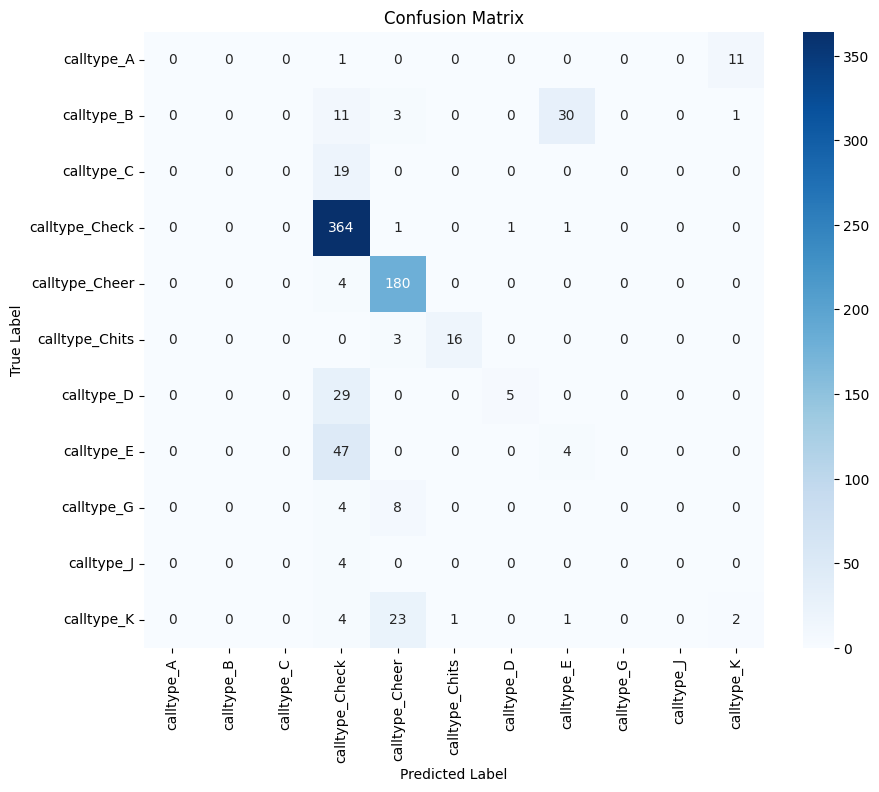

In [28]:
#is there a way to take these outputs and create a confusion matrix that lets us see what classes are being confused with each other?
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')   

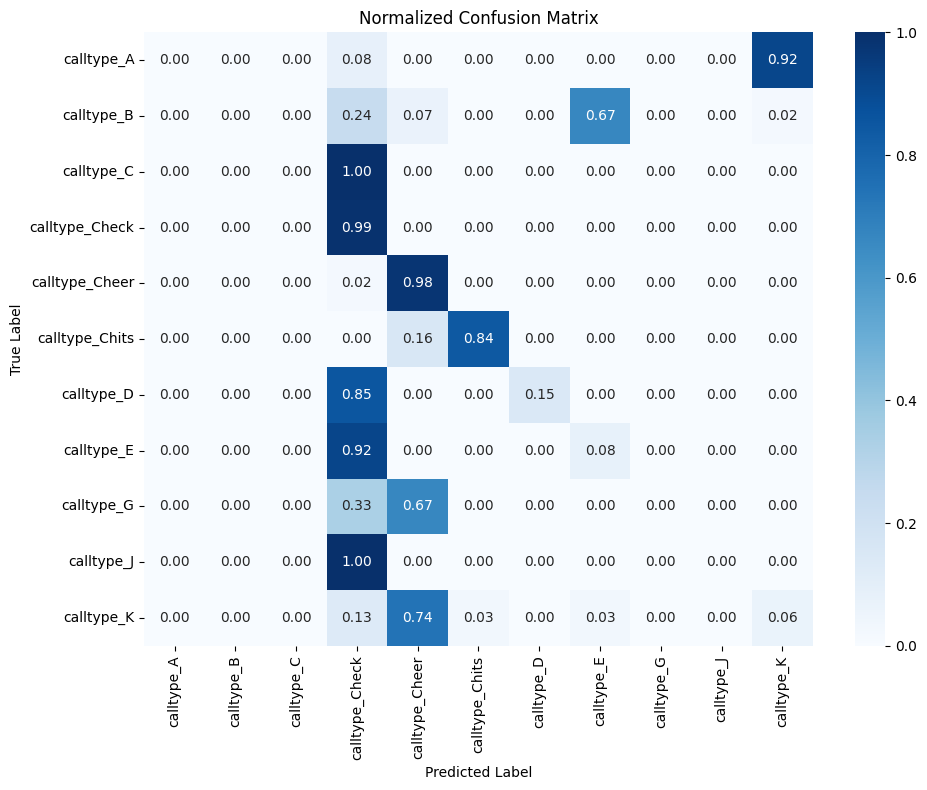

In [29]:
cm = confusion_matrix(test_labels, pred_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

Save the model

In [54]:
birdnet.save("/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/blackbirdcallv1.model")